<a href="https://colab.research.google.com/github/Ranica109/test-1/blob/main/411423215_%E5%87%8C%E7%9D%BF%E8%BE%B0_5_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

解壓完成
data.yaml 建立完成
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=emotion_detection-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

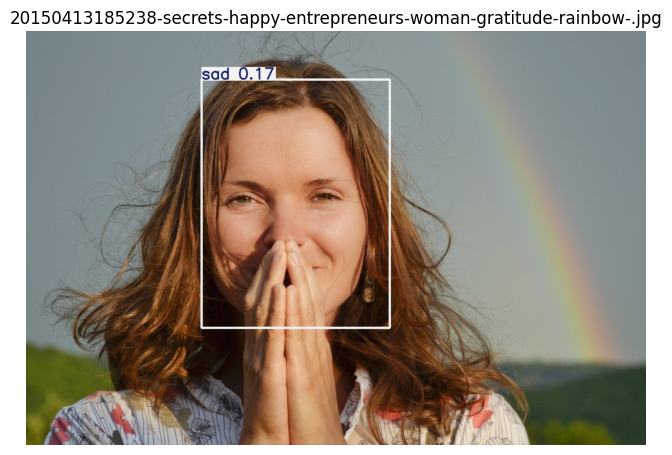

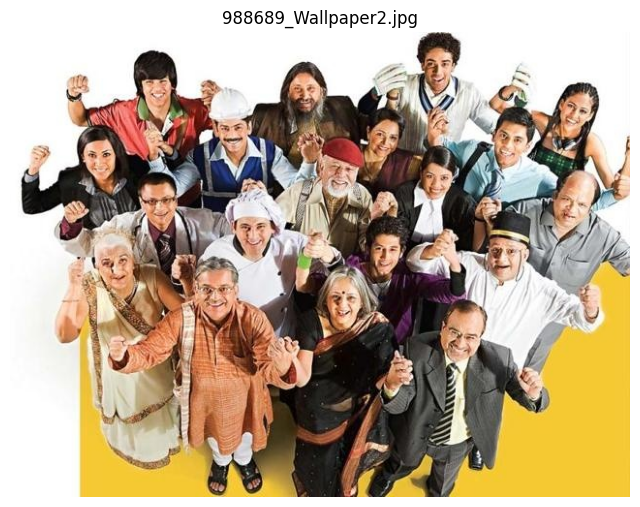

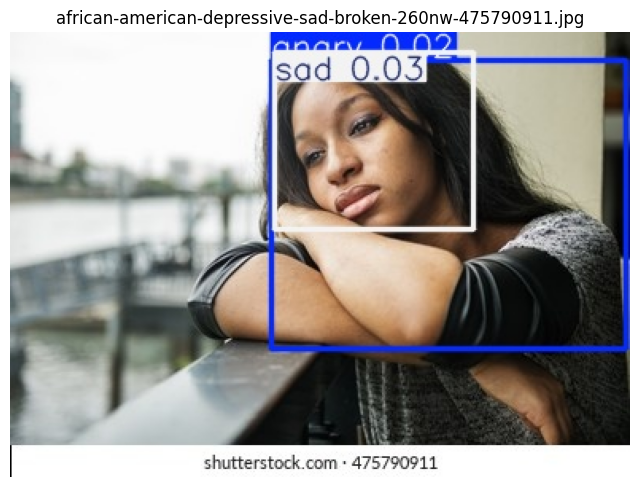

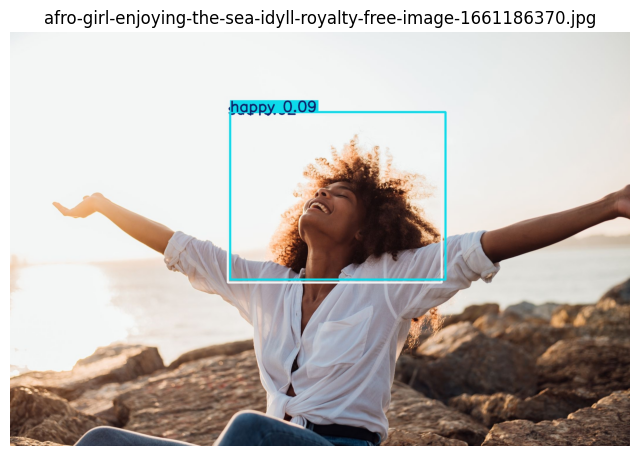

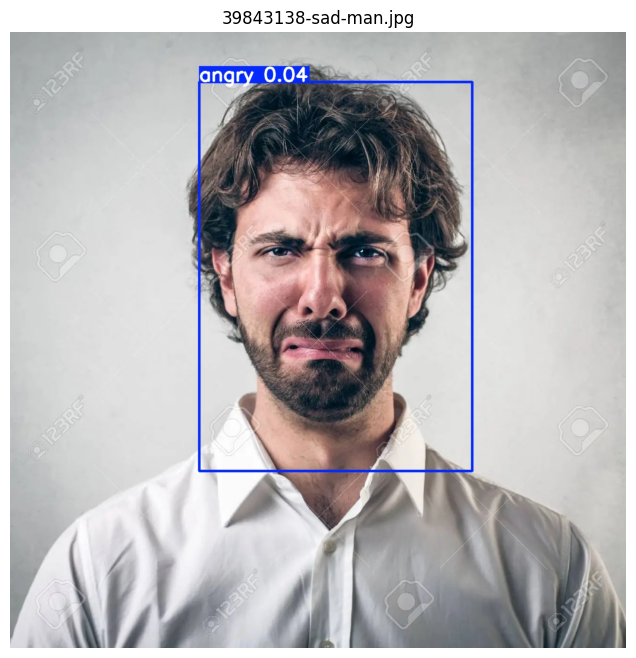

In [ ]:
# ===============================
# 先解壓縮資料夾
# ===============================

import zipfile
with zipfile.ZipFile("/content/face_test.zip", "r") as zip_ref:
    zip_ref.extractall("/content/face_test")
print("解壓完成")


# ===============================
# 1. 安裝 Ultralytics YOLO
# ===============================
!pip install ultralytics

# ===============================
# 2. 載入套件
# ===============================
import yaml
import os
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ===============================
# 3. 資料集路徑
# ===============================
DATASET_PATH = "/content/face_test/face_test"

# ===============================
# 4. 建立 data.yaml
# （情緒偵測版本）
# ===============================
data = {
    "path": DATASET_PATH,

    "train": "train/images",
    "val": "val/images",
    "test": "test/images",

    # ⚠️ 類別一定要跟 MakeSense 標記一致
    "names": {
        0: "angry",
        1: "happy",
        2: "sad"
    }
}

with open("/content/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml 建立完成")

# ===============================
# 5. 載入 YOLOv8 模型
# ===============================
model = YOLO("yolov8n.pt")

# ===============================
# 6. 開始訓練
# ===============================
model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="emotion_detection",
    patience=20
)

# ===============================
# 7. 評估模型
# ===============================
metrics = model.val()
print(metrics)

# ===============================
# 8. 載入最佳模型
# ===============================
best_model = YOLO(
    "runs/detect/emotion_detection/weights/best.pt"
)

# ===============================
# 9. 使用 test 圖片做預測
# ===============================
results = best_model.predict(
    source=f"{DATASET_PATH}/test/images",
    conf=0.02,
    save=True
)

print("預測完成！")

# ===============================
# 10. 顯示預測結果
# ===============================
predict_dirs = glob.glob("runs/detect/predict*")
latest_dir = max(predict_dirs, key=os.path.getmtime)

print("最新 predict 資料夾：", latest_dir)

# 取得所有結果圖片
result_images = os.listdir(latest_dir)

# 顯示圖片
for img_name in result_images:

    img_path = os.path.join(latest_dir, img_name)

    # 讀取圖片
    img = cv2.imread(img_path)

    # BGR → RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 顯示圖片
    plt.figure(figsize=(8,8))
    plt.imshow(img_rgb)
    plt.title(img_name)
    plt.axis("off")
    plt.show()